# Экспериментальные решения

В данном ноутбуке представлены промежуточные эксперименты по кластеризации сигналов сцинтилляционного детектора.

Здесь тестировались разные подходы:

- KMeans;
- IsolationForest + GMM;
- GMM на расширенном наборе признаков;
- GMM на PSD-признаках.

Финальное эталонное решение находится в ноутбуке `Signal_types_classification_Финальное_решение.ipynb`.

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

path = kagglehub.competition_download(
    "signal-types-classification"
)

print("Путь к файлам:", path)

100%|██████████| 13.2M/13.2M [00:00<00:00, 81.2MB/s]

Extracting files...


Путь к файлам: /root/.cache/kagglehub/competitions/signal-types-classification


In [ ]:
import os

os.listdir(path)

['Run200_Wave_0_1.txt', 'test-dataset.ipynb', 'Description.pdf']

In [ ]:
# Импорт библиотек

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")


In [ ]:
file_path = os.path.join(path, "Run200_Wave_0_1.txt")

df = pd.read_csv(
    file_path,
    sep=" ",
    header=None,
    skipinitialspace=True
)

print(df.shape)

display(df.head())

df.info()

(23479, 505)


,0,1,2,3,4,5,6,7,8,9,...,495,496,497,498,499,500,501,502,503,504
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,...,14822,14815,14815,14817,14819,14820,14822,14820,14819,NaN
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,...,14817,14824,14822,14824,14819,14820,14819,14822,14820,NaN
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824,...,14821,14820,14820,14818,14821,14823,14820,14820,14821,NaN
3,15798632,841,123,500,14828,14822,14818,14824,14824,14822,...,14826,14822,14821,14820,14828,14820,14822,14823,14822,NaN
4,20637296,412,348,500,14823,14815,14823,14821,14827,14820,...,14820,14823,14828,14824,14820,14824,14824,14822,14825,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 505 entries, 0 to 504
dtypes: float64(1), int64(504)
memory usage: 90.5 MB


In [ ]:
# Data loading
dataset = pd.read_csv(os.path.join(path, 'Run200_Wave_0_1.txt'),
                      sep=' ',
                      header=None,
                      skipinitialspace=True)
dataset = dataset.drop([0, 1, 2, 3, 504], axis=1)
dataset.columns = list(range(500))
dataset.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [ ]:
dataset.shape

(23479, 500)

In [ ]:
missing = dataset.isnull().sum().sum()
print("Количество пропусков:", missing)

Количество пропусков: 0


Text(0, 0.5, 'bit ADC')

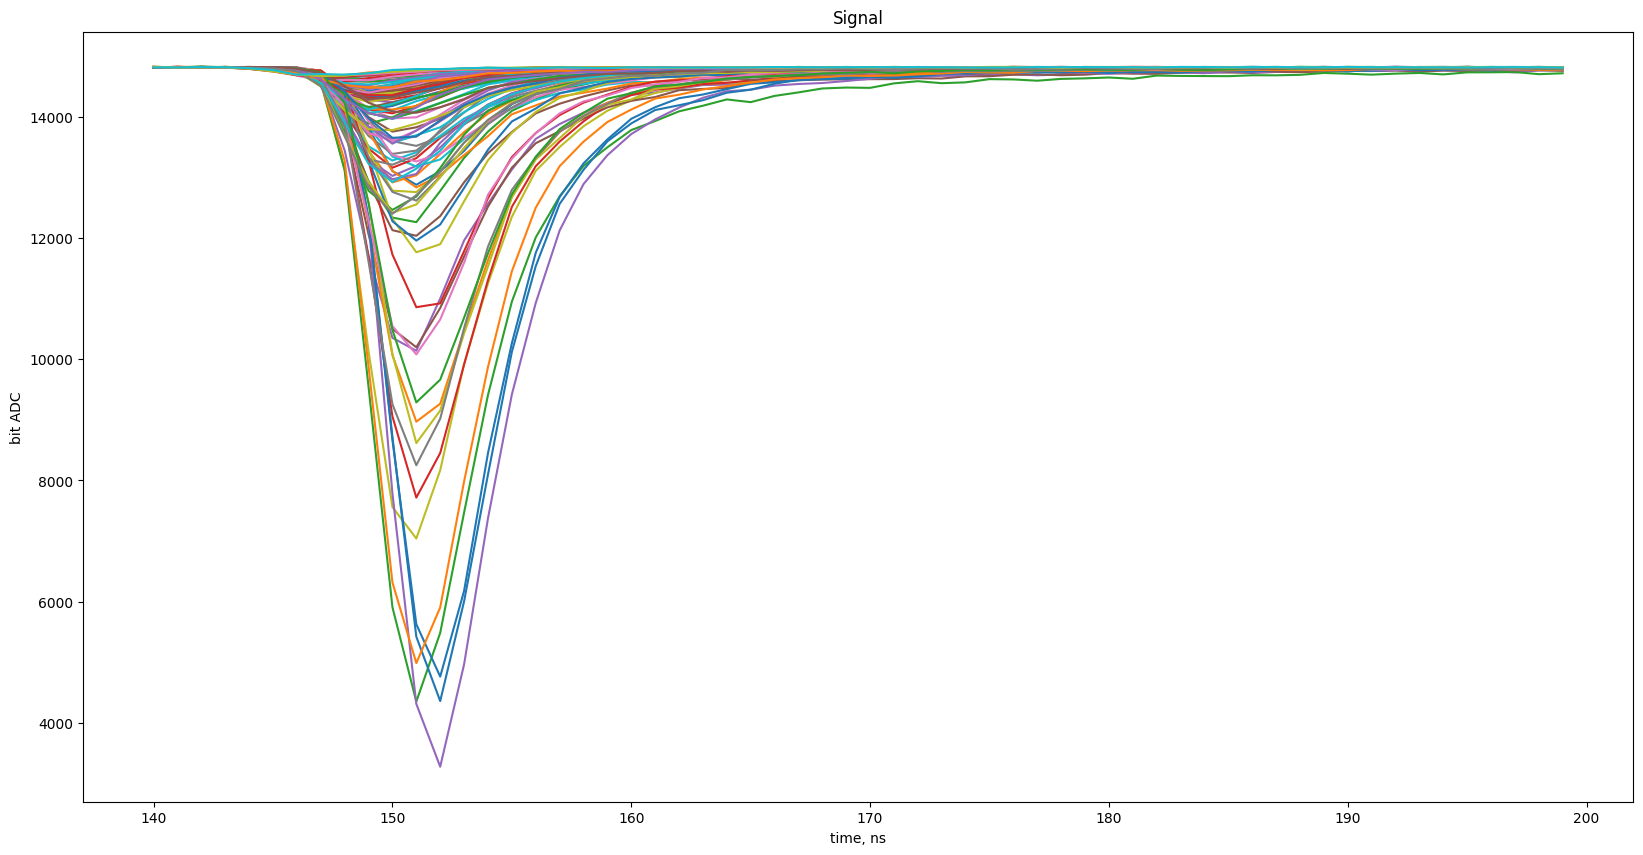

In [ ]:
N=range(0,100)
ax = dataset.T[N][140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

Text(0, 0.5, 'bit ADC')

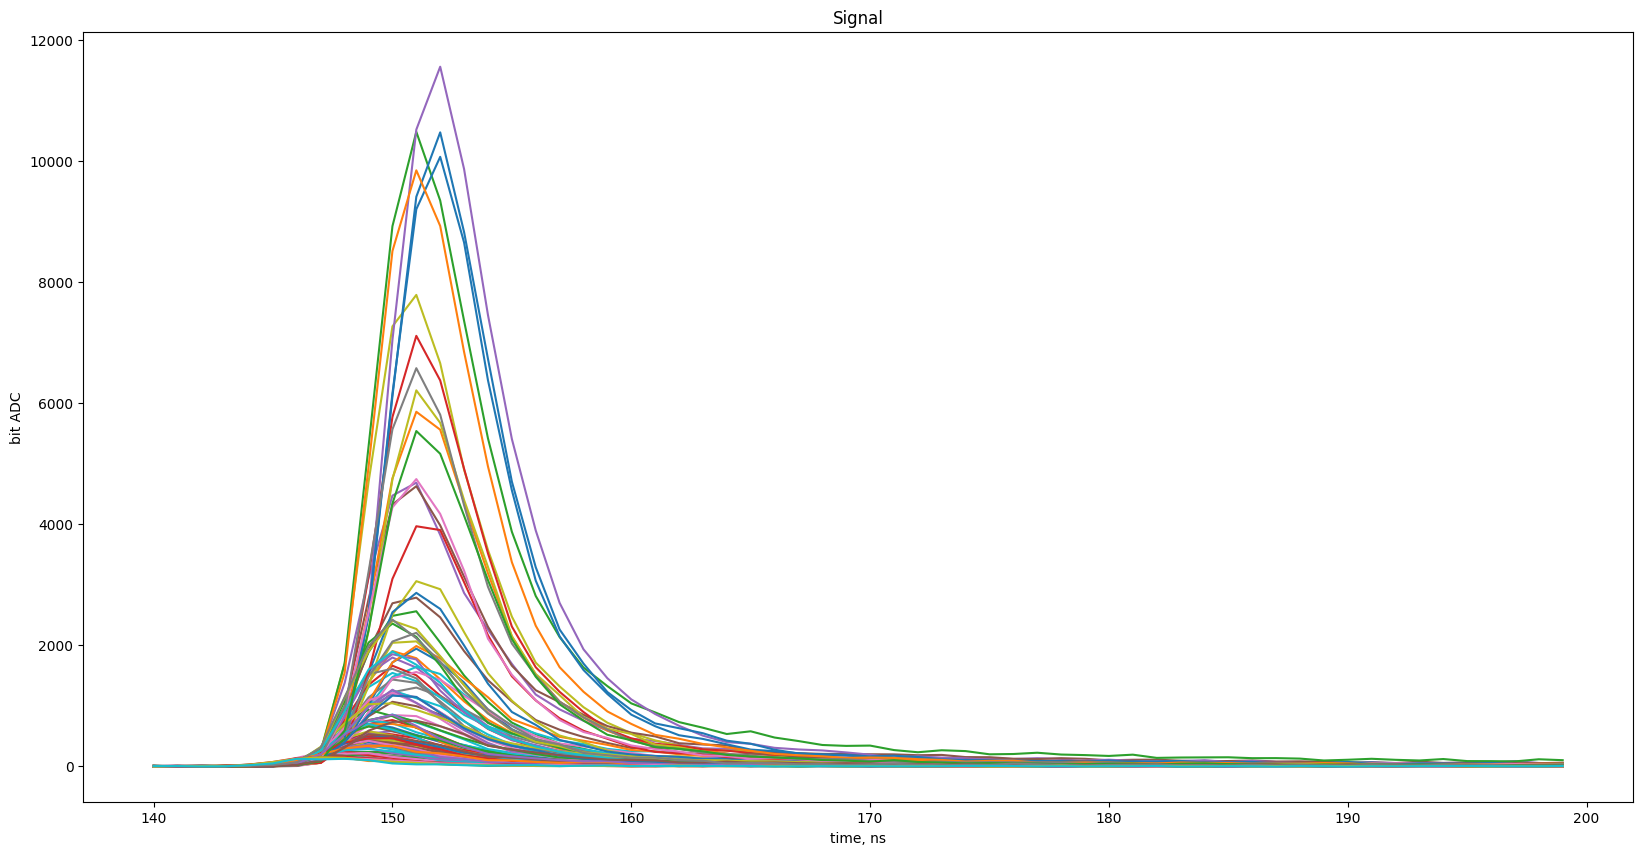

In [ ]:
ax = (2**14-dataset.T[N]-1560)[140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

In [ ]:
# EDA

print("Размер датасета:", dataset.shape)
print("Количество сигналов:", dataset.shape[0])
print("Количество временных отсчетов:", dataset.shape[1])

print("\nПропуски:", dataset.isnull().sum().sum())
print("Дубликаты:", dataset.duplicated().sum())

display(dataset.describe().T.head())

Размер датасета: (23479, 500)
Количество сигналов: 23479
Количество временных отсчетов: 500

Пропуски: 0
Дубликаты: 0


,count,mean,std,min,25%,50%,75%,max
0,23479.0,14822.972316,2.805884,14812.0,14821.0,14823.0,14824.0,14834.0
1,23479.0,14822.958474,2.833516,14812.0,14821.0,14823.0,14824.0,14835.0
2,23479.0,14822.970016,2.840755,14812.0,14821.0,14823.0,14825.0,14834.0
3,23479.0,14822.989991,2.852066,14811.0,14821.0,14823.0,14825.0,14835.0
4,23479.0,14823.003961,2.833412,14812.0,14821.0,14823.0,14825.0,14834.0


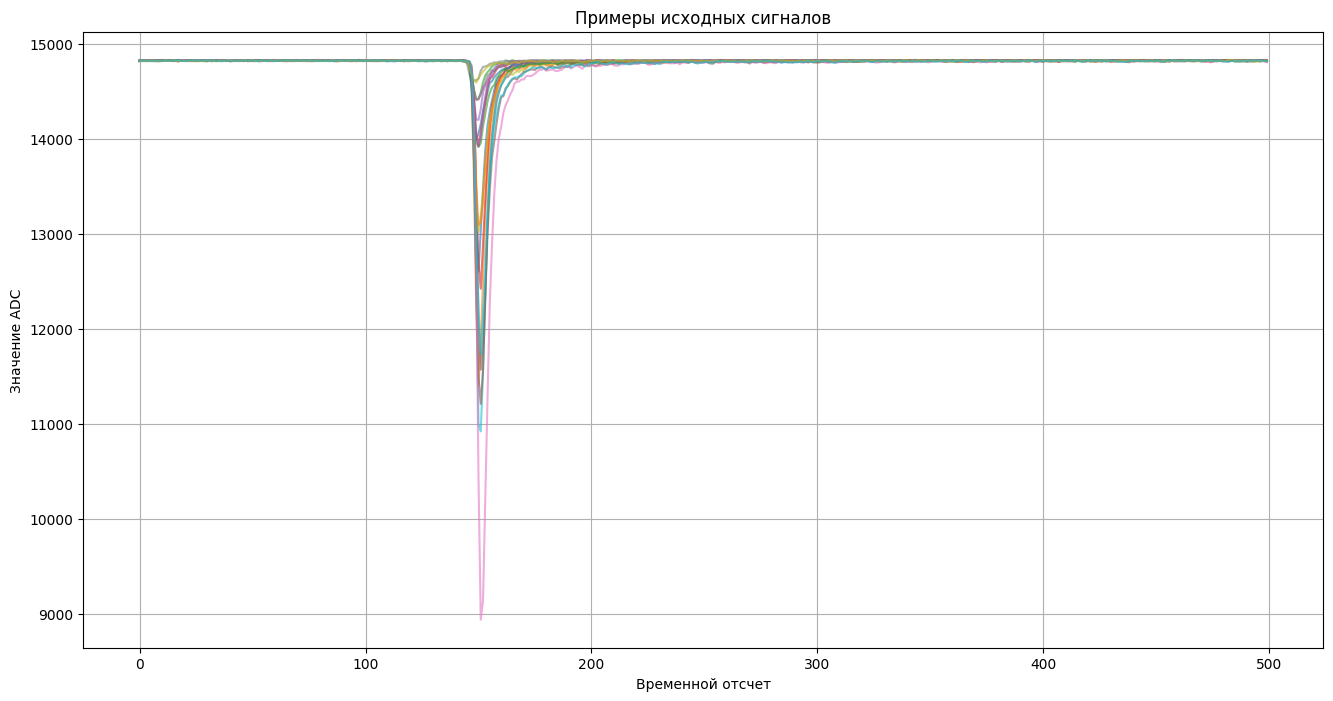

In [ ]:
# Визуализация случайных сигналов

random_indices = np.random.choice(dataset.index, size=20, replace=False)

plt.figure(figsize=(16, 8))

for idx in random_indices:
    plt.plot(dataset.columns, dataset.loc[idx], alpha=0.6)

plt.title("Примеры исходных сигналов")
plt.xlabel("Временной отсчет")
plt.ylabel("Значение ADC")
plt.grid(True)
plt.show()

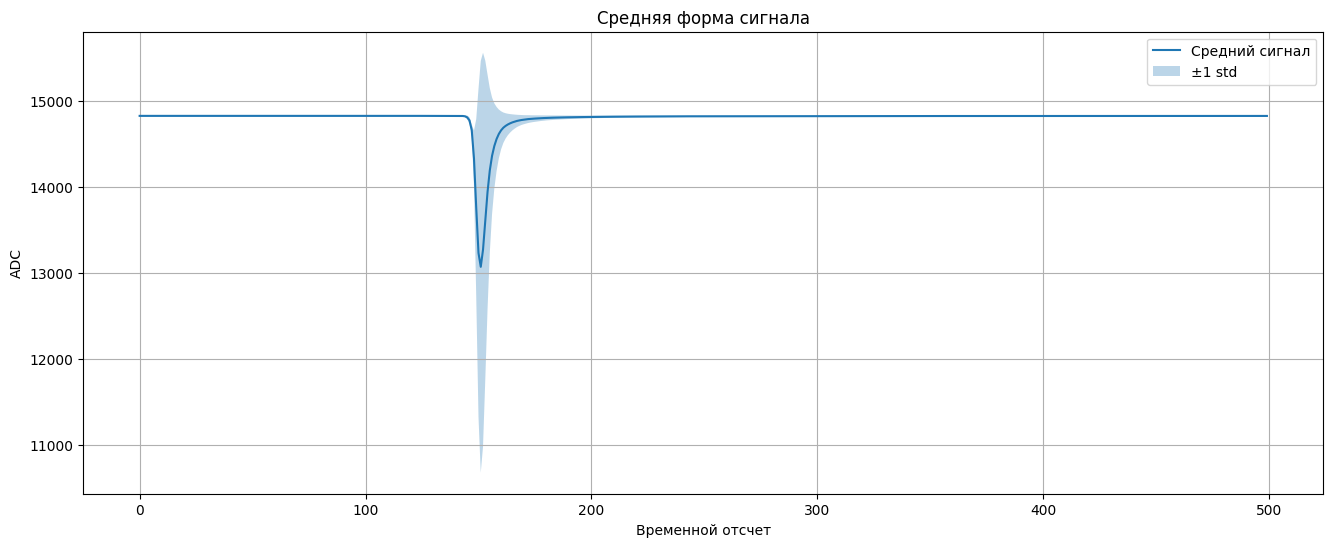

In [ ]:
mean_signal = dataset.mean(axis=0)
std_signal = dataset.std(axis=0)

plt.figure(figsize=(16, 6))
plt.plot(mean_signal, label="Средний сигнал")
plt.fill_between(
    dataset.columns,
    mean_signal - std_signal,
    mean_signal + std_signal,
    alpha=0.3,
    label="±1 std"
)

plt.title("Средняя форма сигнала")
plt.xlabel("Временной отсчет")
plt.ylabel("ADC")
plt.legend()
plt.grid(True)
plt.show()

По результатам EDA видно, что сигналы имеют отрицательную форму: полезный импульс соответствует резкому падению значения ADC относительно базовой линии.  
Поэтому перед построением признаков необходимо выполнить:

1. Оценку базовой линии сигнала;
2. Вычитание baseline;
3. Инверсию сигнала, чтобы импульс стал положительным;
4. Проверку результата визуализацией.

In [ ]:
# Baseline correction + инверсия сигнала

signals_raw = dataset.copy()

# Baseline будем оценивать по начальной части сигнала до импульса.
# Судя по графикам, импульс начинается примерно после 140-го отсчета,
# поэтому первые 100 отсчетов можно использовать как baseline.
baseline_window = list(range(0, 100))

baseline = signals_raw.iloc[:, baseline_window].mean(axis=1)

# Вычитаем baseline и инвертируем сигнал
signals_processed = -(signals_raw.sub(baseline, axis=0))

signals_processed.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,1.13,-1.87,-2.87,-0.87,3.13,1.13,-2.87,-0.87,1.13,1.13,...,-6.87,-0.87,6.13,6.13,4.13,2.13,1.13,-0.87,1.13,2.13
1,2.47,0.47,2.47,-3.53,-1.53,0.47,2.47,0.47,-0.53,1.47,...,-5.53,5.47,-1.53,0.47,-1.53,3.47,2.47,3.47,0.47,2.47
2,1.92,1.92,-0.08,-3.08,1.92,-2.08,-2.08,2.92,-1.08,-2.08,...,1.92,0.92,1.92,1.92,3.92,0.92,-1.08,1.92,1.92,0.92
3,-5.24,0.76,4.76,-1.24,-1.24,0.76,2.76,0.76,-1.24,2.76,...,-1.24,-3.24,0.76,1.76,2.76,-5.24,2.76,0.76,-0.24,0.76
4,-1.57,6.43,-1.57,0.43,-5.57,1.43,-1.57,-2.57,5.43,0.43,...,1.43,1.43,-1.57,-6.57,-2.57,1.43,-2.57,-2.57,-0.57,-3.57


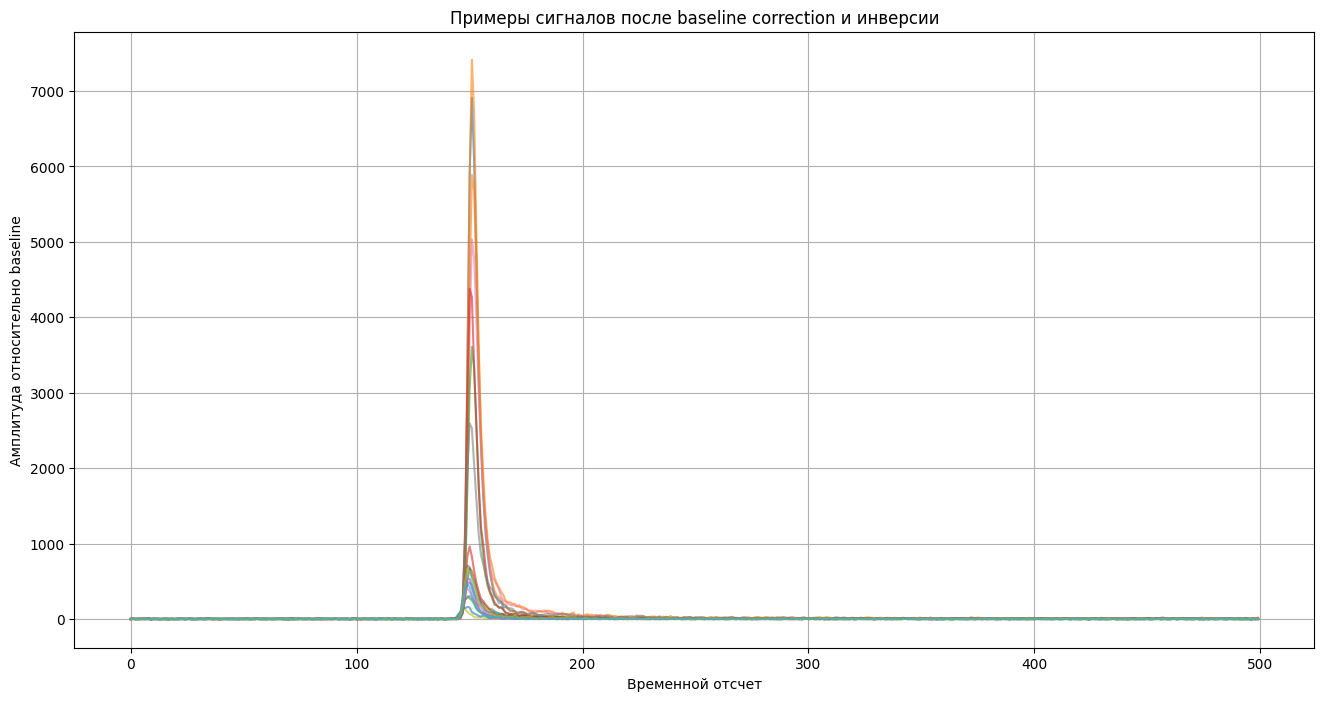

In [ ]:
# Визуализация обработанных сигналов

random_indices = np.random.choice(signals_processed.index, size=20, replace=False)

plt.figure(figsize=(16, 8))

for idx in random_indices:
    plt.plot(signals_processed.columns, signals_processed.loc[idx], alpha=0.6)

plt.title("Примеры сигналов после baseline correction и инверсии")
plt.xlabel("Временной отсчет")
plt.ylabel("Амплитуда относительно baseline")
plt.grid(True)
plt.show()

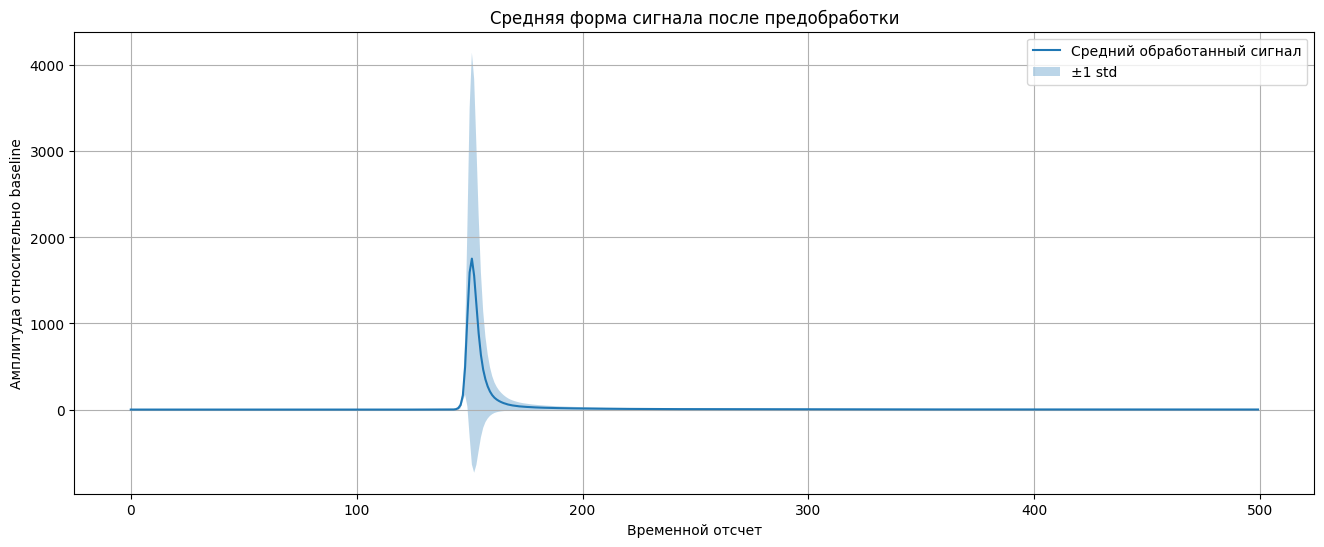

In [ ]:
mean_processed = signals_processed.mean(axis=0)
std_processed = signals_processed.std(axis=0)

plt.figure(figsize=(16, 6))
plt.plot(mean_processed, label="Средний обработанный сигнал")
plt.fill_between(
    signals_processed.columns,
    mean_processed - std_processed,
    mean_processed + std_processed,
    alpha=0.3,
    label="±1 std"
)

plt.title("Средняя форма сигнала после предобработки")
plt.xlabel("Временной отсчет")
plt.ylabel("Амплитуда относительно baseline")
plt.legend()
plt.grid(True)
plt.show()

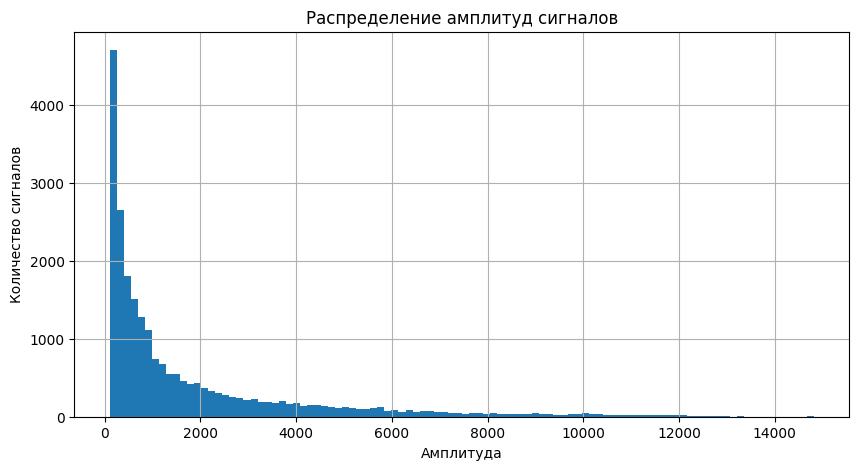

count    23479.000000
mean      1835.103314
std       2389.301353
min        104.230000
25%        308.220000
50%        812.720000
75%       2315.270000
max      14824.820000
dtype: float64


In [ ]:
amplitudes = signals_processed.max(axis=1)

plt.figure(figsize=(10, 5))
plt.hist(amplitudes, bins=100)
plt.title("Распределение амплитуд сигналов")
plt.xlabel("Амплитуда")
plt.ylabel("Количество сигналов")
plt.grid(True)
plt.show()

print(amplitudes.describe())

In [ ]:
# Feature Engineering

signals = signals_processed.copy()

features = pd.DataFrame(index=signals.index)

# Базовые признаки
features["amplitude"] = signals.max(axis=1)
features["min_value"] = signals.min(axis=1)
features["mean"] = signals.mean(axis=1)
features["std"] = signals.std(axis=1)

# Положение максимума
features["peak_pos"] = signals.values.argmax(axis=1)

# Интеграл по всему сигналу
features["total_integral"] = signals.sum(axis=1)

# Окно вокруг импульса
# По графикам пик находится около 150
# Возьмем несколько фиксированных областей
features["pre_peak_integral"] = signals.iloc[:, 120:145].sum(axis=1)
features["peak_integral"] = signals.iloc[:, 145:160].sum(axis=1)
features["fast_integral"] = signals.iloc[:, 145:170].sum(axis=1)
features["tail_integral"] = signals.iloc[:, 170:230].sum(axis=1)
features["long_tail_integral"] = signals.iloc[:, 230:350].sum(axis=1)

# Отношения интегралов
eps = 1e-9

features["tail_to_total"] = features["tail_integral"] / (features["total_integral"] + eps)
features["fast_to_total"] = features["fast_integral"] / (features["total_integral"] + eps)
features["tail_to_fast"] = features["tail_integral"] / (features["fast_integral"] + eps)
features["peak_to_total"] = features["peak_integral"] / (features["total_integral"] + eps)

# Нормированные признаки формы
features["integral_to_amplitude"] = features["total_integral"] / (features["amplitude"] + eps)
features["tail_to_amplitude"] = features["tail_integral"] / (features["amplitude"] + eps)

features.head()

,amplitude,min_value,mean,std,peak_pos,total_integral,pre_peak_integral,peak_integral,fast_integral,tail_integral,long_tail_integral,tail_to_total,fast_to_total,tail_to_fast,peak_to_total,integral_to_amplitude,tail_to_amplitude
0,530.13,-8.87,9.228,46.208472,149,4614.0,23.25,3242.95,3530.25,644.8,253.6,0.139749,0.765117,0.182650,0.702850,8.703526,1.216305
1,1901.47,-5.53,24.696,163.272112,150,12348.0,25.75,10734.05,11330.75,553.2,232.4,0.044801,0.917618,0.048823,0.869295,6.493923,0.290933
2,2557.92,-8.08,33.910,225.369832,151,16955.0,14.00,14880.80,15870.00,533.2,330.4,0.031448,0.936007,0.033598,0.877664,6.628432,0.208451
3,564.76,-8.24,9.316,50.120565,149,4658.0,15.00,3433.40,3767.00,540.6,205.2,0.116058,0.808716,0.143509,0.737097,8.247751,0.957221
4,1793.43,-6.57,23.212,156.545416,150,11606.0,-10.25,10361.45,10958.75,474.8,105.6,0.040910,0.944231,0.043326,0.892767,6.471398,0.264744


In [ ]:
print("Размер таблицы признаков:", features.shape)

display(features.describe().T)

Размер таблицы признаков: (23479, 17)


,count,mean,std,min,25%,50%,75%,max
amplitude,23479.0,1835.103314,2389.301353,104.230000,308.220000,812.720000,2315.270000,14824.820000
min_value,23479.0,-7.746253,1.234035,-15.520000,-8.530000,-7.670000,-6.880000,-3.970000
mean,23479.0,26.281382,32.194186,0.766000,4.876000,12.484000,34.633000,226.132000
std,23479.0,161.693850,208.973628,10.231617,27.740063,72.155612,204.672726,1484.918725
peak_pos,23479.0,149.628604,2.489996,145.000000,149.000000,150.000000,151.000000,472.000000
total_integral,23479.0,13140.691128,16097.092930,383.000000,2438.000000,6242.000000,17316.500000,113066.000000
pre_peak_integral,23479.0,6.829039,19.176516,-86.500000,-5.250000,5.500000,16.000000,229.250000
peak_integral,23479.0,10710.831415,13585.435770,533.150000,1908.575000,4912.950000,13692.975000,97347.650000
fast_integral,23479.0,11619.427190,14655.767851,560.250000,2074.625000,5346.250000,14923.125000,105454.250000
tail_integral,23479.0,946.849406,1115.793954,-90.400000,182.500000,502.600000,1323.400000,8102.400000


In [ ]:
print("Пропуски:", features.isnull().sum().sum())
print("Бесконечности:", np.isinf(features.values).sum())

features = features.replace([np.inf, -np.inf], np.nan)
features = features.fillna(features.median())

Пропуски: 0
Бесконечности: 0


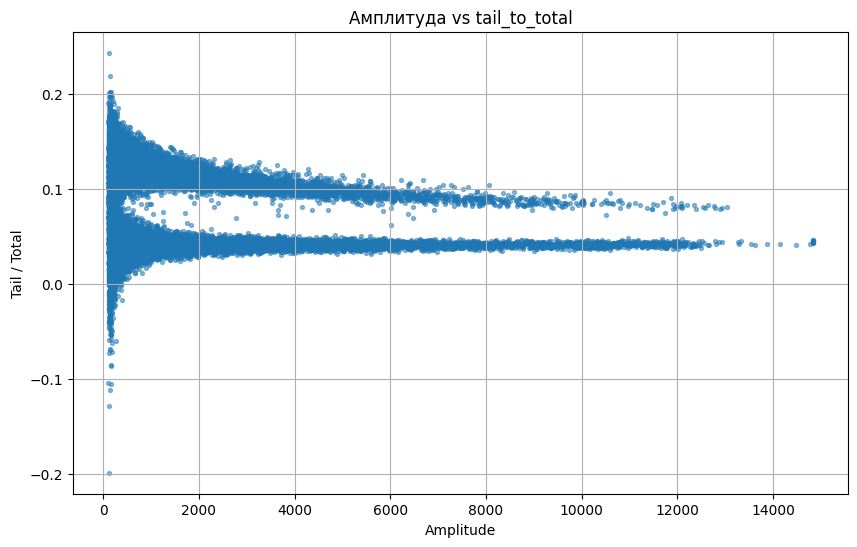

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(
    features["amplitude"],
    features["tail_to_total"],
    s=8,
    alpha=0.5
)

plt.title("Амплитуда vs tail_to_total")
plt.xlabel("Amplitude")
plt.ylabel("Tail / Total")
plt.grid(True)
plt.show()

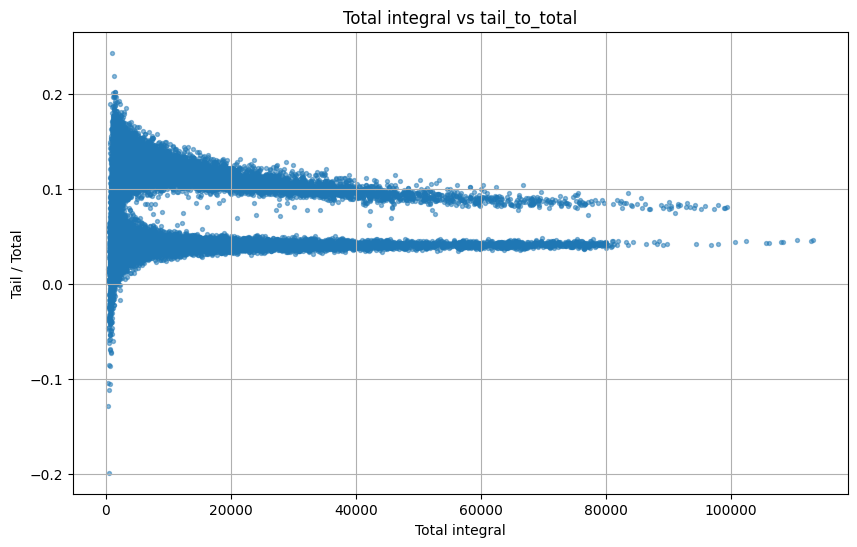

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(
    features["total_integral"],
    features["tail_to_total"],
    s=8,
    alpha=0.5
)

plt.title("Total integral vs tail_to_total")
plt.xlabel("Total integral")
plt.ylabel("Tail / Total")
plt.grid(True)
plt.show()

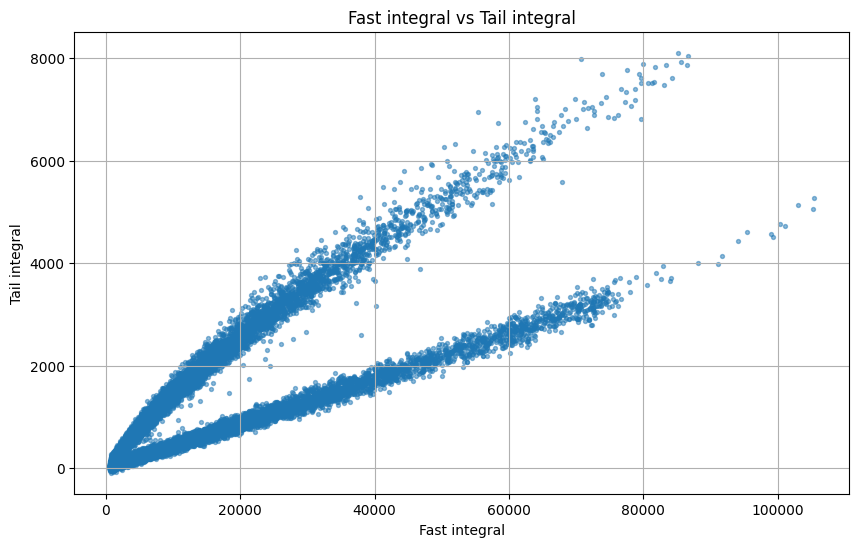

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(
    features["fast_integral"],
    features["tail_integral"],
    s=8,
    alpha=0.5
)

plt.title("Fast integral vs Tail integral")
plt.xlabel("Fast integral")
plt.ylabel("Tail integral")
plt.grid(True)
plt.show()

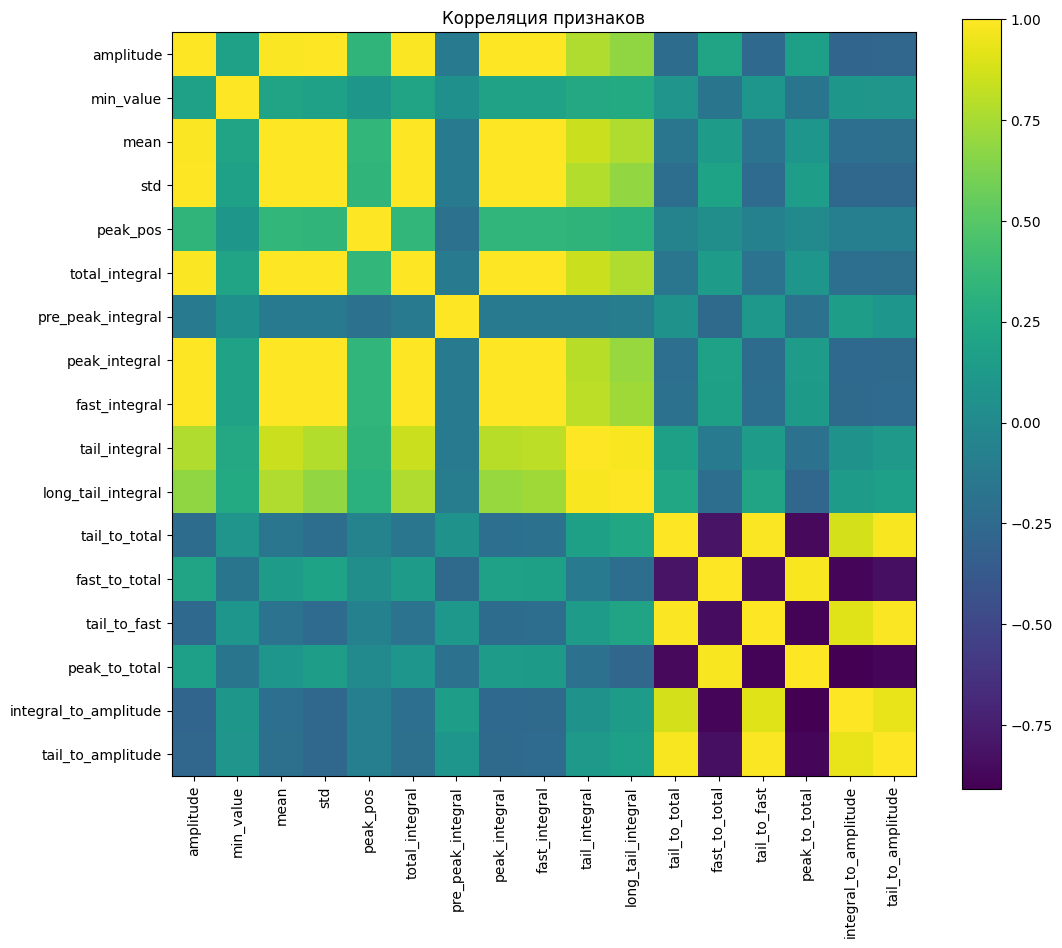

In [ ]:
plt.figure(figsize=(12, 10))
corr = features.corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Корреляция признаков")
plt.show()

Для кластеризации были выбраны признаки, описывающие как интенсивность сигнала, так и его форму:

- `amplitude` — максимальная амплитуда импульса;
- `total_integral` — полная площадь сигнала;
- `tail_to_total` — доля хвостовой части;
- `tail_to_fast` — отношение хвоста к быстрой компоненте;
- `integral_to_amplitude` — ширина/растянутость импульса;
- `peak_pos` — положение максимума.

Такой набор позволяет учитывать не только размер сигнала, но и различия в форме импульса.

In [ ]:
selected_features = [
    "amplitude",
    "total_integral",
    "tail_to_total",
    "tail_to_fast",
    "integral_to_amplitude",
    "peak_pos"
]

X = features[selected_features].copy()

display(X.head())
print("Размер матрицы признаков:", X.shape)

,amplitude,total_integral,tail_to_total,tail_to_fast,integral_to_amplitude,peak_pos
0,530.13,4614.0,0.139749,0.182650,8.703526,149
1,1901.47,12348.0,0.044801,0.048823,6.493923,150
2,2557.92,16955.0,0.031448,0.033598,6.628432,151
3,564.76,4658.0,0.116058,0.143509,8.247751,149
4,1793.43,11606.0,0.040910,0.043326,6.471398,150


Размер матрицы признаков: (23479, 6)


In [ ]:
# масштабирование признаков
from sklearn.preprocessing import RobustScaler, StandardScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=selected_features,
    index=X.index
)

display(X_scaled.head())

,amplitude,total_integral,tail_to_total,tail_to_fast,integral_to_amplitude,peak_pos
0,-0.140799,-0.109420,0.718638,0.804957,0.408579,-0.5
1,0.542463,0.410391,-0.531687,-0.507703,-0.452096,0.0
2,0.869535,0.720032,-0.707525,-0.657038,-0.399703,0.5
3,-0.123545,-0.106462,0.406672,0.421042,0.231048,-0.5
4,0.488633,0.360520,-0.582925,-0.561619,-0.460870,0.0


Доля объясненной дисперсии:
[0.58508761 0.23839354]
Суммарно: 0.8234811484459105


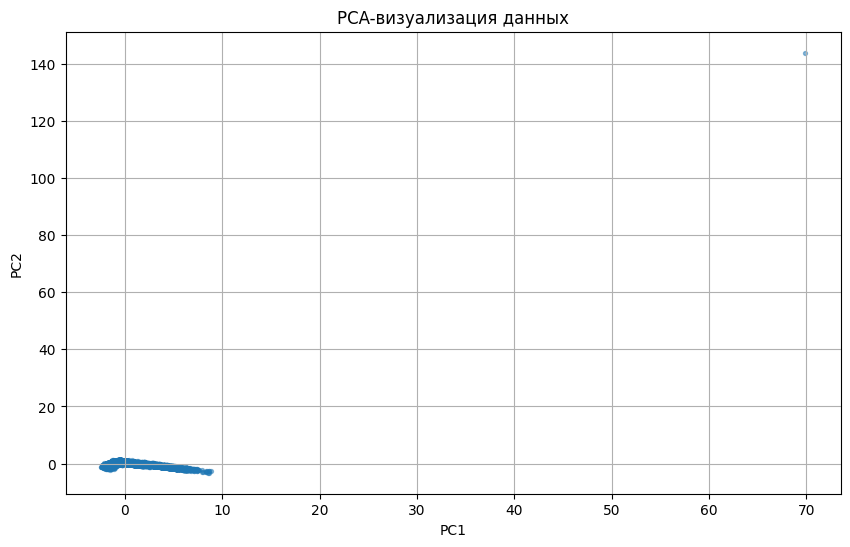

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=X.index
)

print("Доля объясненной дисперсии:")
print(pca.explained_variance_ratio_)
print("Суммарно:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(10, 6))
plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    s=8,
    alpha=0.5
)

plt.title("PCA-визуализация данных")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()


На PCA-визуализации обнаружена одна или несколько сильно удалённых точек.  
Так как по условию задачи один из трёх кластеров соответствует аномальным или неидентифицируемым сигналам, необходимо отдельно проанализировать выбросы и проверить, не образуют ли они отдельную группу.

,distance_from_center
count,23479.000000
mean,1.375407
std,1.521332
min,0.033431
25%,0.754477
50%,1.119501
75%,1.565994
max,159.871387


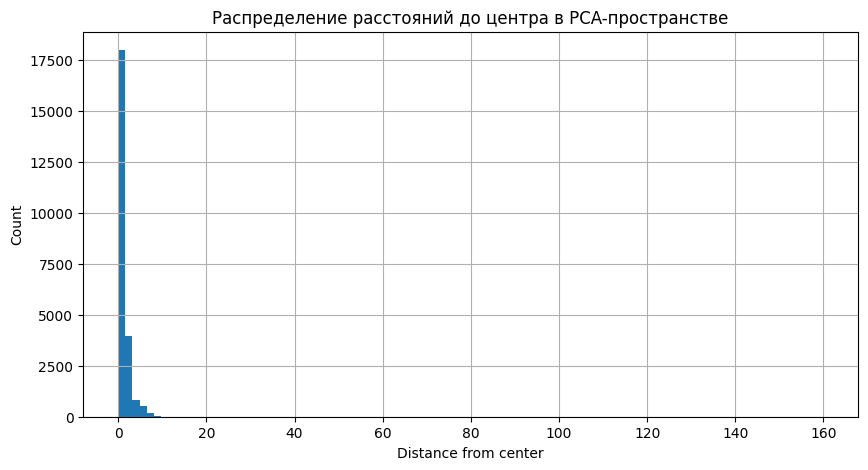

In [ ]:
# Анализ выбросов в PCA-пространстве

pca_df["distance_from_center"] = np.sqrt(
    pca_df["PC1"] ** 2 + pca_df["PC2"] ** 2
)

display(pca_df["distance_from_center"].describe())

plt.figure(figsize=(10, 5))
plt.hist(pca_df["distance_from_center"], bins=100)
plt.title("Распределение расстояний до центра в PCA-пространстве")
plt.xlabel("Distance from center")
plt.ylabel("Count")
plt.grid(True)
plt.show()

In [ ]:
# Индексы самых удаленных точек
top_outliers = pca_df.sort_values("distance_from_center", ascending=False).head(20)

display(top_outliers)

,PC1,PC2,distance_from_center
1929,69.915820,143.772871,159.871387
9553,8.821342,-2.758175,9.242489
798,8.594116,-3.203747,9.171849
23118,8.512643,-3.170368,9.083849
13595,8.654410,-2.702734,9.066619
17790,8.637966,-2.695542,9.048779
22310,8.352302,-3.119619,8.915883
9190,8.337130,-3.112453,8.899163
6401,8.434329,-2.618848,8.831550
11289,8.367545,-2.595990,8.760991


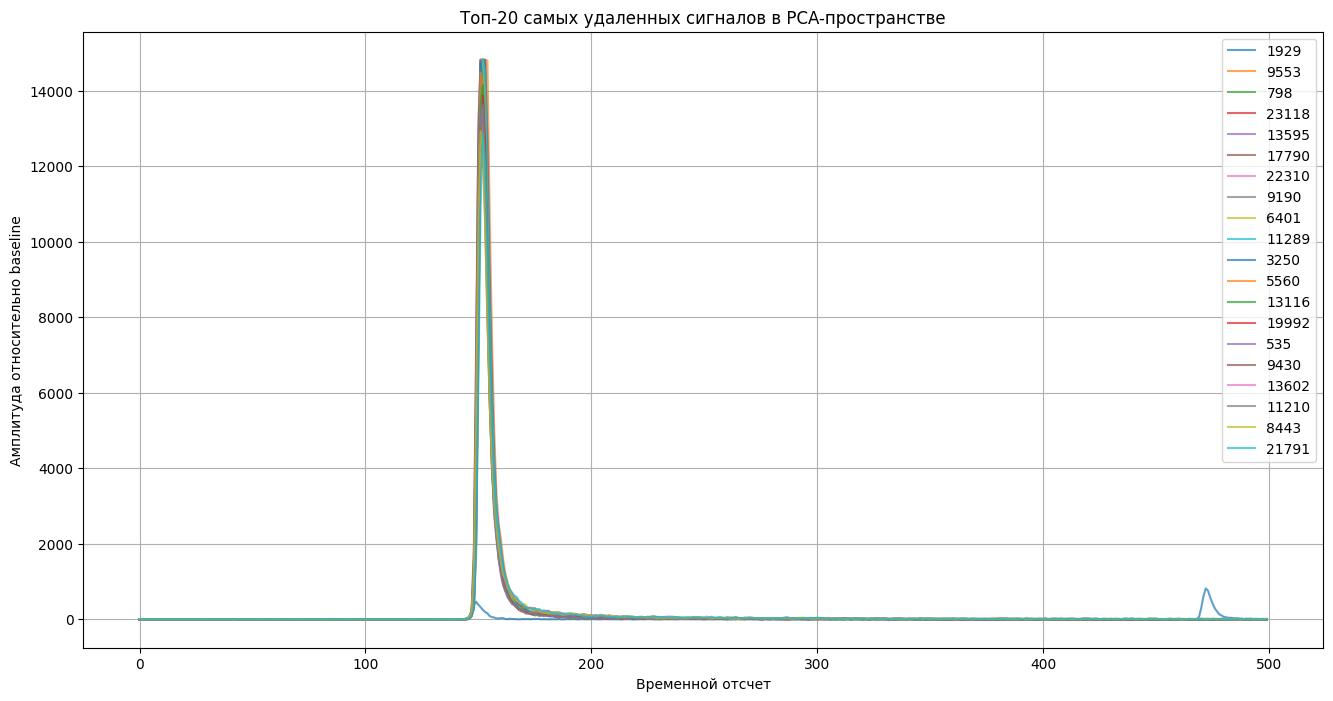

In [ ]:
# Визуализация самых аномальных сигналов

outlier_indices = top_outliers.index

plt.figure(figsize=(16, 8))

for idx in outlier_indices:
    plt.plot(signals_processed.columns, signals_processed.loc[idx], alpha=0.7, label=str(idx))

plt.title("Топ-20 самых удаленных сигналов в PCA-пространстве")
plt.xlabel("Временной отсчет")
plt.ylabel("Амплитуда относительно baseline")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Дополнительные признаки для поздних аномалий

# Поздняя область, где у аномального сигнала виден второй пик
late_window = signals.iloc[:, 430:500]

features["late_max"] = late_window.max(axis=1)
features["late_integral"] = late_window.sum(axis=1)

# Отношение поздней активности к основной амплитуде и полной площади
eps = 1e-9

features["late_max_to_amplitude"] = features["late_max"] / (features["amplitude"] + eps)
features["late_integral_to_total"] = features["late_integral"] / (features["total_integral"] + eps)

display(features[[
    "amplitude",
    "total_integral",
    "late_max",
    "late_integral",
    "late_max_to_amplitude",
    "late_integral_to_total"
]].describe().T)

,count,mean,std,min,25%,50%,75%,max
amplitude,23479.0,1835.103314,2389.301353,104.230000,308.220000,812.720000,2315.270000,14824.820000
total_integral,23479.0,13140.691128,16097.092930,383.000000,2438.000000,6242.000000,17316.500000,113066.000000
late_max,23479.0,8.722719,6.190810,2.630000,6.390000,7.840000,10.400000,819.710000
late_integral,23479.0,58.094144,88.218226,-135.100000,4.200000,40.400000,90.600000,4746.700000
late_max_to_amplitude,23479.0,0.015637,0.016626,0.000508,0.004094,0.009712,0.022690,1.000000
late_integral_to_total,23479.0,0.004340,0.017054,-0.208717,0.000656,0.004801,0.009826,0.601305


In [ ]:
late_outliers = features.sort_values(
    "late_max_to_amplitude",
    ascending=False
).head(20)

display(late_outliers[[
    "amplitude",
    "total_integral",
    "late_max",
    "late_integral",
    "late_max_to_amplitude",
    "late_integral_to_total",
    "peak_pos"
]])

,amplitude,total_integral,late_max,late_integral,late_max_to_amplitude,late_integral_to_total,peak_pos
1929,819.71,7894.0,819.71,4746.7,1.000000,0.601305,472
4230,139.81,926.0,16.81,59.7,0.120235,0.064471,147
1724,120.79,1266.0,13.79,-0.7,0.114165,-0.000553,148
3980,109.06,1183.0,12.06,85.2,0.110581,0.072020,145
20699,127.67,1334.0,13.67,50.9,0.107073,0.038156,147
8671,112.28,1190.0,11.28,59.6,0.100463,0.050084,145
1446,119.95,658.0,11.95,-28.5,0.099625,-0.043313,147
18883,115.14,1169.0,11.14,36.8,0.096752,0.031480,148
21392,118.43,983.0,11.43,-13.9,0.096513,-0.014140,146
11911,155.83,1550.0,14.83,45.1,0.095168,0.029097,147


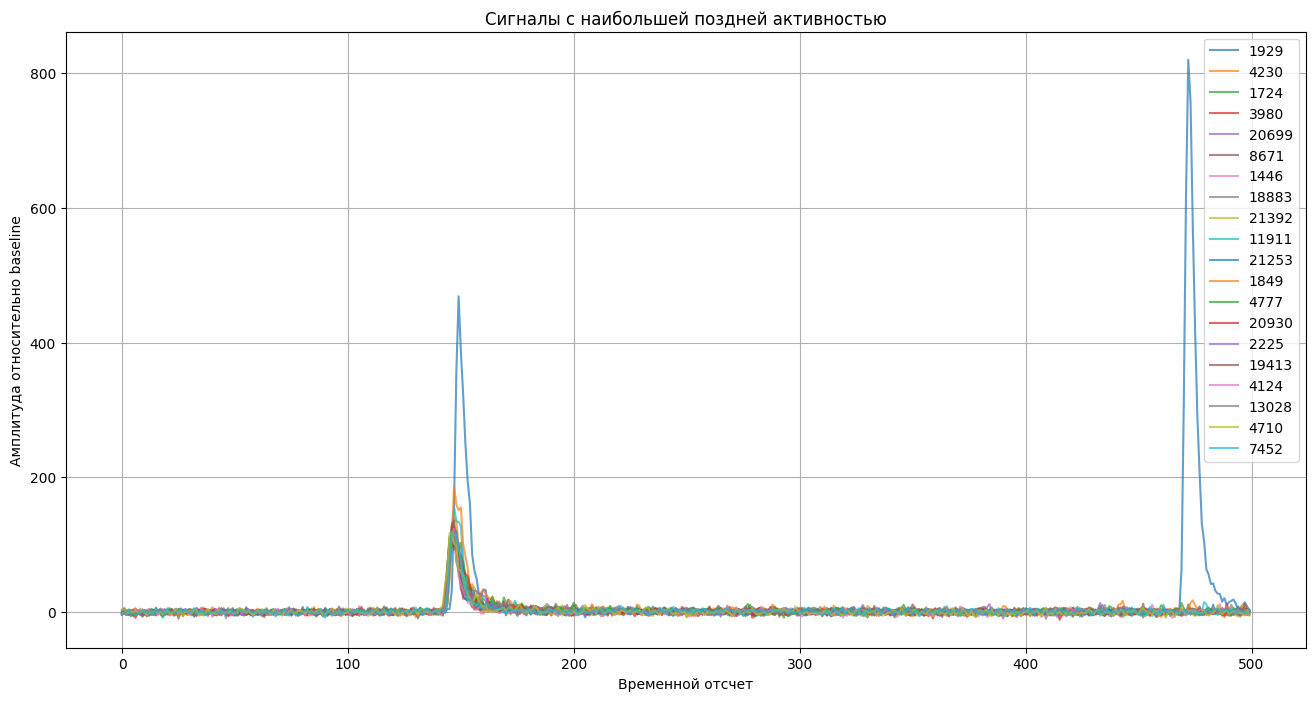

In [ ]:
late_outlier_indices = late_outliers.index

plt.figure(figsize=(16, 8))

for idx in late_outlier_indices:
    plt.plot(signals_processed.columns, signals_processed.loc[idx], alpha=0.7, label=str(idx))

plt.title("Сигналы с наибольшей поздней активностью")
plt.xlabel("Временной отсчет")
plt.ylabel("Амплитуда относительно baseline")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Обновленный набор признаков

selected_features_v2 = [
    "amplitude",
    "fast_integral",
    "tail_integral",
    "tail_to_total",
    "tail_to_fast",
    "integral_to_amplitude",
    "peak_pos",
    "late_max_to_amplitude",
    "late_integral_to_total"
]

X_v2 = features[selected_features_v2].copy()

# Проверка
display(X_v2.head())
print("Размер матрицы признаков:", X_v2.shape)

,amplitude,fast_integral,tail_integral,tail_to_total,tail_to_fast,integral_to_amplitude,peak_pos,late_max_to_amplitude,late_integral_to_total
0,530.13,3530.25,644.8,0.139749,0.182650,8.703526,149,0.011563,0.009991
1,1901.47,11330.75,553.2,0.044801,0.048823,6.493923,150,0.003929,0.007038
2,2557.92,15870.00,533.2,0.031448,0.033598,6.628432,151,0.003096,0.004211
3,564.76,3767.00,540.6,0.116058,0.143509,8.247751,149,0.010199,0.007128
4,1793.43,10958.75,474.8,0.040910,0.043326,6.471398,150,0.003028,0.002077


Размер матрицы признаков: (23479, 9)


In [ ]:
from sklearn.preprocessing import RobustScaler

scaler_v2 = RobustScaler()

X_scaled_v2 = scaler_v2.fit_transform(X_v2)

X_scaled_v2 = pd.DataFrame(
    X_scaled_v2,
    columns=selected_features_v2,
    index=X_v2.index
)

display(X_scaled_v2.head())

,amplitude,fast_integral,tail_integral,tail_to_total,tail_to_fast,integral_to_amplitude,peak_pos,late_max_to_amplitude,late_integral_to_total
0,-0.140799,-0.141339,0.124638,0.718638,0.804957,0.408579,-0.5,0.099568,0.566089
1,0.542463,0.465774,0.044351,-0.531687,-0.507703,-0.452096,0.0,-0.310989,0.243964
2,0.869535,0.819064,0.026821,-0.707525,-0.657038,-0.399703,0.5,-0.355745,-0.064276
3,-0.123545,-0.122913,0.033307,0.406672,0.421042,0.231048,-0.5,0.026209,0.253773
4,0.488633,0.436821,-0.024367,-0.582925,-0.561619,-0.460870,0.0,-0.359431,-0.297071


In [ ]:
## Эксперимент 1. KMeans

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

kmeans_v2 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=50
)

clusters_kmeans_v2 = kmeans_v2.fit_predict(X_scaled_v2)

features["cluster_kmeans_v2"] = clusters_kmeans_v2

print("Размеры кластеров:")
print(pd.Series(clusters_kmeans_v2).value_counts().sort_index())

print("\nМетрики качества кластеризации:")
print("Silhouette score:", silhouette_score(X_scaled_v2, clusters_kmeans_v2))
print("Davies-Bouldin score:", davies_bouldin_score(X_scaled_v2, clusters_kmeans_v2))
print("Calinski-Harabasz score:", calinski_harabasz_score(X_scaled_v2, clusters_kmeans_v2))

Размеры кластеров:
0     2152
1     4550
2    16777
Name: count, dtype: int64

Метрики качества кластеризации:
Silhouette score: 0.3902620954863829
Davies-Bouldin score: 0.9486859655501014
Calinski-Harabasz score: 8286.827904396532


In [ ]:
## Эксперимент 2. IsolationForest + GMM


from sklearn.ensemble import IsolationForest
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

anomaly_features = [
    "amplitude",
    "total_integral",
    "tail_to_total",
    "tail_to_fast",
    "integral_to_amplitude",
    "peak_pos",
    "late_max_to_amplitude",
    "late_integral_to_total"
]

X_anom = features[anomaly_features].copy()

scaler_anom = RobustScaler()
X_anom_scaled = scaler_anom.fit_transform(X_anom)

In [ ]:
iso = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

iso_labels = iso.fit_predict(X_anom_scaled)

features["is_anomaly"] = (iso_labels == -1).astype(int)

print("Количество аномалий:")
print(features["is_anomaly"].value_counts())

Количество аномалий:
is_anomaly
0    22305
1     1174
Name: count, dtype: int64


In [ ]:
print("Сигнал 1929:")
display(features.loc[[1929], anomaly_features + ["is_anomaly"]])

Сигнал 1929:


,amplitude,total_integral,tail_to_total,tail_to_fast,integral_to_amplitude,peak_pos,late_max_to_amplitude,late_integral_to_total,is_anomaly
1929,819.71,7894.0,0.024652,0.071577,9.630235,472,1.0,0.601305,1


In [ ]:
from sklearn.mixture import GaussianMixture

normal_mask = features["is_anomaly"] == 0

particle_features = [
    "tail_to_total",
    "tail_to_fast",
    "integral_to_amplitude",
    "amplitude",
    "fast_integral",
    "tail_integral"
]

X_particles = features.loc[normal_mask, particle_features].copy()

scaler_particles = RobustScaler()
X_particles_scaled = scaler_particles.fit_transform(X_particles)

gmm = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=42,
    n_init=10
)

particle_clusters = gmm.fit_predict(X_particles_scaled)

features["cluster_iso_gmm"] = -1
features.loc[normal_mask, "cluster_iso_gmm"] = particle_clusters

In [ ]:
# 0 и 1 — два типа частиц
# 2 - аномальные / неидентифицируемые сигналы

features.loc[features["is_anomaly"] == 1, "cluster_iso_gmm"] = 2
features["cluster_iso_gmm"] = features["cluster_iso_gmm"].astype(int)

print("Размеры итоговых кластеров:")
print(features["cluster_iso_gmm"].value_counts().sort_index())

Размеры итоговых кластеров:
cluster_iso_gmm
0    12606
1     9699
2     1174
Name: count, dtype: int64


In [ ]:
final_clusters = features["cluster_iso_gmm"].values

print("Метрики итоговой модели IsolationForest + GMM:")
print("Silhouette score:", silhouette_score(X_scaled_v2, final_clusters))
print("Davies-Bouldin score:", davies_bouldin_score(X_scaled_v2, final_clusters))
print("Calinski-Harabasz score:", calinski_harabasz_score(X_scaled_v2, final_clusters))

Метрики итоговой модели IsolationForest + GMM:
Silhouette score: 0.2119028821117058
Davies-Bouldin score: 3.614532139826208
Calinski-Harabasz score: 2538.505989130195


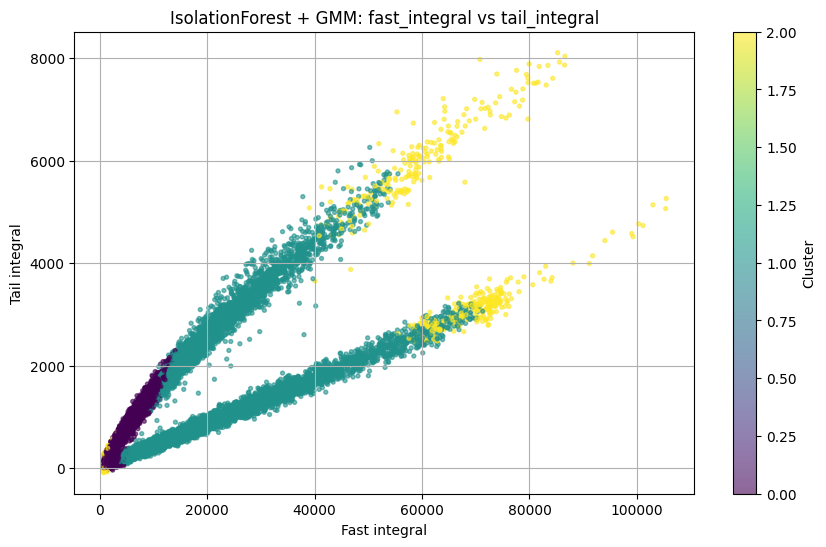

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    features["fast_integral"],
    features["tail_integral"],
    c=features["cluster_iso_gmm"],
    s=8,
    alpha=0.6,
    cmap="viridis"
)

plt.title("IsolationForest + GMM: fast_integral vs tail_integral")
plt.xlabel("Fast integral")
plt.ylabel("Tail integral")
plt.grid(True)
plt.colorbar(label="Cluster")
plt.show()

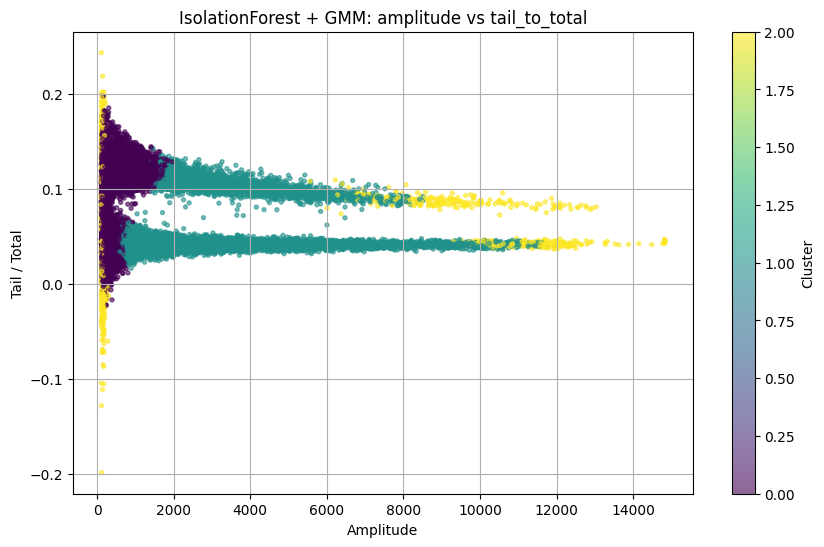

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    features["amplitude"],
    features["tail_to_total"],
    c=features["cluster_iso_gmm"],
    s=8,
    alpha=0.6,
    cmap="viridis"
)

plt.title("IsolationForest + GMM: amplitude vs tail_to_total")
plt.xlabel("Amplitude")
plt.ylabel("Tail / Total")
plt.grid(True)
plt.colorbar(label="Cluster")
plt.show()

In [ ]:
contamination_values = [0.005, 0.01, 0.02, 0.03, 0.04, 0.05]

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

results = []

contamination_values = [0.005, 0.01, 0.02, 0.03, 0.04, 0.05]

anomaly_features = [
    "amplitude",
    "total_integral",
    "tail_to_total",
    "tail_to_fast",
    "integral_to_amplitude",
    "peak_pos",
    "late_max_to_amplitude",
    "late_integral_to_total"
]

particle_features = [
    "tail_to_total",
    "tail_to_fast",
    "integral_to_amplitude",
    "amplitude",
    "fast_integral",
    "tail_integral"
]

for contamination in contamination_values:
    # IsolationForest
    X_anom = features[anomaly_features].copy()
    scaler_anom = RobustScaler()
    X_anom_scaled = scaler_anom.fit_transform(X_anom)

    iso = IsolationForest(
        n_estimators=300,
        contamination=contamination,
        random_state=42,
        n_jobs=-1
    )

    iso_labels = iso.fit_predict(X_anom_scaled)
    is_anomaly = (iso_labels == -1)

    # GMM на нормальных сигналах
    normal_mask = ~is_anomaly

    X_particles = features.loc[normal_mask, particle_features].copy()
    scaler_particles = RobustScaler()
    X_particles_scaled = scaler_particles.fit_transform(X_particles)

    gmm = GaussianMixture(
        n_components=2,
        covariance_type="full",
        random_state=42,
        n_init=10
    )

    particle_clusters = gmm.fit_predict(X_particles_scaled)

    # Итоговые кластеры
    final_labels = np.full(len(features), 2)
    final_labels[normal_mask] = particle_clusters

    # Метрики
    sil = silhouette_score(X_scaled_v2, final_labels)
    db = davies_bouldin_score(X_scaled_v2, final_labels)
    ch = calinski_harabasz_score(X_scaled_v2, final_labels)

    counts = pd.Series(final_labels).value_counts().sort_index()

    results.append({
        "contamination": contamination,
        "cluster_0": counts.get(0, 0),
        "cluster_1": counts.get(1, 0),
        "cluster_2_anomaly": counts.get(2, 0),
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch,
        "signal_1929_cluster": final_labels[1929]
    })

results_df = pd.DataFrame(results)
display(results_df)

,contamination,cluster_0,cluster_1,cluster_2_anomaly,silhouette,davies_bouldin,calinski_harabasz,signal_1929_cluster
0,0.005,10197,13164,118,0.230551,3.184588,2863.714150,2
1,0.010,13079,10165,235,0.229559,3.338564,2839.457989,2
2,0.020,12945,10064,470,0.225381,3.441567,2773.162229,2
3,0.030,12818,9956,705,0.221439,3.565860,2689.719005,2
4,0.040,9862,12677,940,0.216029,3.552183,2625.891011,2
5,0.050,12606,9699,1174,0.211903,3.614532,2538.505989,2


In [ ]:
best_contamination = 0.005

X_anom = features[anomaly_features].copy()

scaler_anom = RobustScaler()
X_anom_scaled = scaler_anom.fit_transform(X_anom)

iso_best = IsolationForest(
    n_estimators=300,
    contamination=best_contamination,
    random_state=42,
    n_jobs=-1
)

iso_labels_best = iso_best.fit_predict(X_anom_scaled)
features["is_anomaly_best"] = (iso_labels_best == -1).astype(int)

normal_mask = features["is_anomaly_best"] == 0

X_particles = features.loc[normal_mask, particle_features].copy()

scaler_particles = RobustScaler()
X_particles_scaled = scaler_particles.fit_transform(X_particles)

gmm_best = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=42,
    n_init=10
)

particle_clusters = gmm_best.fit_predict(X_particles_scaled)

features["cluster_best"] = 2
features.loc[normal_mask, "cluster_best"] = particle_clusters
features["cluster_best"] = features["cluster_best"].astype(int)

print("Размеры итоговых кластеров:")
print(features["cluster_best"].value_counts().sort_index())

print("\nСигнал 1929:")
print(features.loc[1929, "cluster_best"])

Размеры итоговых кластеров:
cluster_best
0    10197
1    13164
2      118
Name: count, dtype: int64

Сигнал 1929:
2


In [ ]:
# Медианы tail_to_total для двух физических кластеров
particle_cluster_medians = (
    features[features["cluster_best"] != 2]
    .groupby("cluster_best")["tail_to_total"]
    .median()
    .sort_values()
)

display(particle_cluster_medians)

low_tail_cluster = particle_cluster_medians.index[0]
high_tail_cluster = particle_cluster_medians.index[1]

cluster_mapping = {
    low_tail_cluster: 0,
    high_tail_cluster: 1,
    2: 2
}

features["cluster_final"] = features["cluster_best"].map(cluster_mapping).astype(int)

print("Преобразование кластеров:")
print(cluster_mapping)

print("\nРазмеры финальных кластеров:")
print(features["cluster_final"].value_counts().sort_index())

,tail_to_total
cluster_best,
0,0.043730
1,0.112127


Преобразование кластеров:
{np.int64(0): 0, np.int64(1): 1, 2: 2}

Размеры финальных кластеров:
cluster_final
0    10197
1    13164
2      118
Name: count, dtype: int64


In [ ]:
display(
    features.groupby("cluster_final")[[
        "amplitude",
        "fast_integral",
        "tail_integral",
        "tail_to_total",
        "tail_to_fast",
        "integral_to_amplitude",
        "peak_pos",
        "late_max_to_amplitude",
        "late_integral_to_total"
    ]].median()
)

,amplitude,fast_integral,tail_integral,tail_to_total,tail_to_fast,integral_to_amplitude,peak_pos,late_max_to_amplitude,late_integral_to_total
cluster_final,,,,,,,,,
0,2700.480,17370.000,1274.0,0.043730,0.046864,6.484090,151.0,0.003599,0.003325
1,355.370,2377.625,253.6,0.112127,0.139244,8.750434,149.0,0.020091,0.007085
2,142.835,913.500,148.8,0.068253,0.090506,7.480800,147.0,0.040483,0.003862


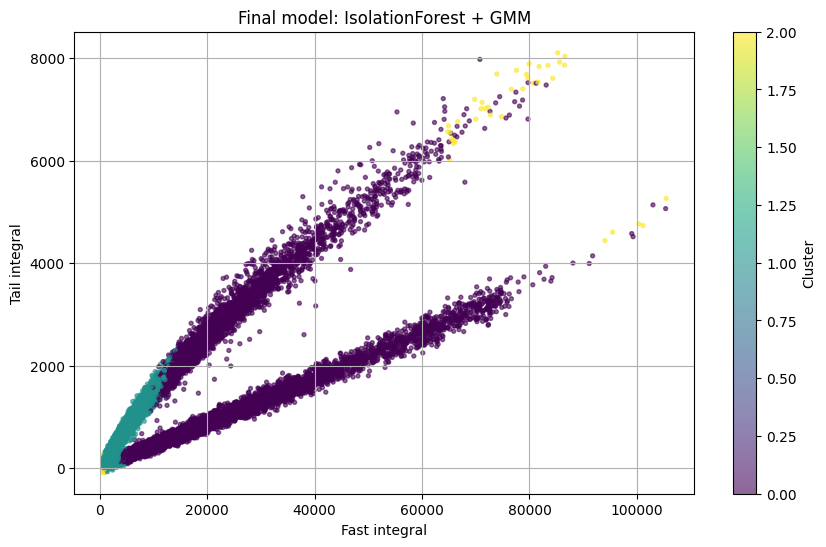

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    features["fast_integral"],
    features["tail_integral"],
    c=features["cluster_final"],
    s=8,
    alpha=0.6,
    cmap="viridis"
)

plt.title("Final model: IsolationForest + GMM")
plt.xlabel("Fast integral")
plt.ylabel("Tail integral")
plt.grid(True)
plt.colorbar(label="Cluster")
plt.show()

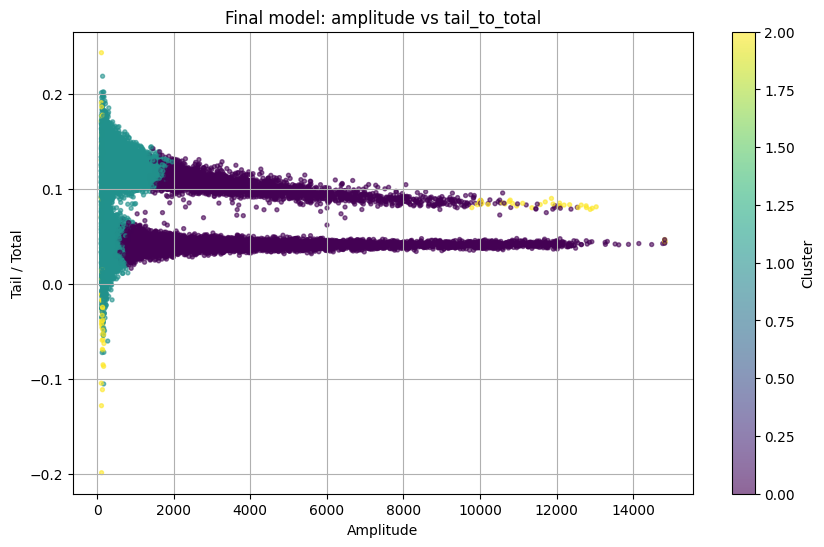

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    features["amplitude"],
    features["tail_to_total"],
    c=features["cluster_final"],
    s=8,
    alpha=0.6,
    cmap="viridis"
)

plt.title("Final model: amplitude vs tail_to_total")
plt.xlabel("Amplitude")
plt.ylabel("Tail / Total")
plt.grid(True)
plt.colorbar(label="Cluster")
plt.show()

In [ ]:
submission = pd.DataFrame({
    "index": features.index,
    "cluster": features["cluster_final"].values
})

submission.head()

,index,cluster
0,0,1
1,1,0
2,2,0
3,3,1
4,4,0


In [ ]:
print(submission.shape)
print(submission["cluster"].value_counts().sort_index())
print(submission.head())
print(submission.tail())

(23479, 2)
cluster
0    10197
1    13164
2      118
Name: count, dtype: int64
   index  cluster
0      0        1
1      1        0
2      2        0
3      3        1
4      4        0
       index  cluster
23474  23474        1
23475  23475        0
23476  23476        0
23477  23477        1
23478  23478        0


In [ ]:
submission.to_csv("submission.csv", index=False)

In [ ]:
from google.colab import files

files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# KMeans

print("Размеры исходных KMeans-кластеров:")
print(features["cluster_kmeans_v2"].value_counts().sort_index())

# Перенумерация кластеров по медиане tail_to_total
# 0 - меньший tail_to_total
# 1 - средний tail_to_total
# 2 - больший tail_to_total

cluster_order = (
    features
    .groupby("cluster_kmeans_v2")["tail_to_total"]
    .median()
    .sort_values()
    .index
)

mapping = {
    cluster_order[0]: 0,
    cluster_order[1]: 1,
    cluster_order[2]: 2
}

features["cluster_kmeans_final"] = (
    features["cluster_kmeans_v2"]
    .map(mapping)
    .astype(int)
)

print("Mapping:", mapping)

print("\nРазмеры финальных KMeans-кластеров:")
print(features["cluster_kmeans_final"].value_counts().sort_index())

display(
    features.groupby("cluster_kmeans_final")[[
        "amplitude",
        "fast_integral",
        "tail_integral",
        "tail_to_total",
        "tail_to_fast",
        "integral_to_amplitude",
        "peak_pos",
        "late_max_to_amplitude",
        "late_integral_to_total"
    ]].median()
)

Размеры исходных KMeans-кластеров:
cluster_kmeans_v2
0     2152
1     4550
2    16777
Name: count, dtype: int64
Mapping: {np.int32(1): 0, np.int32(0): 1, np.int32(2): 2}

Размеры финальных KMeans-кластеров:
cluster_kmeans_final
0     4550
1     2152
2    16777
Name: count, dtype: int64


,amplitude,fast_integral,tail_integral,tail_to_total,tail_to_fast,integral_to_amplitude,peak_pos,late_max_to_amplitude,late_integral_to_total
cluster_kmeans_final,,,,,,,,,
0,5219.475,32304.875,2485.0,0.044211,0.047266,6.492840,151.0,0.002030,0.003069
1,198.445,1281.250,81.8,0.049752,0.050768,6.267395,148.0,0.028858,-0.022025
2,674.130,4510.500,402.2,0.103794,0.127357,8.365813,150.0,0.011652,0.006699


In [ ]:
submission_kmeans = pd.DataFrame({
    "index": features.index,
    "cluster": features["cluster_kmeans_final"].values
})

print(submission_kmeans.shape)
print(submission_kmeans["cluster"].value_counts().sort_index())
display(submission_kmeans.head())
display(submission_kmeans.tail())

submission_kmeans.to_csv("submission_kmeans.csv", index=False)

(23479, 2)
cluster
0     4550
1     2152
2    16777
Name: count, dtype: int64


,index,cluster
0,0,2
1,1,2
2,2,2
3,3,2
4,4,2


,index,cluster
23474,23474,2
23475,23475,0
23476,23476,0
23477,23477,2
23478,23478,0


In [ ]:
from google.colab import files
files.download("submission_kmeans.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Эксперимент 3. GMM на расширенных признаках

features["log_amplitude"] = np.log1p(features["amplitude"])
features["log_total_integral"] = np.log1p(features["total_integral"])
features["log_fast_integral"] = np.log1p(features["fast_integral"])
features["log_tail_integral"] = np.log1p(features["tail_integral"].clip(lower=0))

gmm_features = [
    "tail_to_total",
    "tail_to_fast",
    "integral_to_amplitude",
    "log_amplitude",
    "log_total_integral"
]

X_gmm = features[gmm_features].copy()

display(X_gmm.head())
print("Размер X_gmm:", X_gmm.shape)

,tail_to_total,tail_to_fast,integral_to_amplitude,log_amplitude,log_total_integral
0,0.139749,0.182650,8.703526,6.275007,8.437067
1,0.044801,0.048823,6.493923,7.550908,9.421330
2,0.031448,0.033598,6.628432,7.847341,9.738377
3,0.116058,0.143509,8.247751,6.338170,8.446556
4,0.040910,0.043326,6.471398,7.492443,9.359364


Размер X_gmm: (23479, 5)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_gmm = StandardScaler()
X_gmm_scaled = scaler_gmm.fit_transform(X_gmm)

X_gmm_scaled = pd.DataFrame(
    X_gmm_scaled,
    columns=gmm_features,
    index=features.index
)

display(X_gmm_scaled.head())

,tail_to_total,tail_to_fast,integral_to_amplitude,log_amplitude,log_total_integral
0,1.421194,1.507203,0.641650,-0.411585,-0.306845
1,-0.839921,-0.849815,-0.804430,0.623591,0.513432
2,-1.157909,-1.117963,-0.716400,0.864095,0.777656
3,0.857028,0.817844,0.343368,-0.360339,-0.298937
4,-0.932580,-0.946627,-0.819172,0.576156,0.461789


In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

gmm3 = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42,
    n_init=20
)

clusters_gmm3 = gmm3.fit_predict(X_gmm_scaled)

features["cluster_gmm3"] = clusters_gmm3

print("Размеры GMM-кластеров:")
print(features["cluster_gmm3"].value_counts().sort_index())

print("\nМетрики:")
print("Silhouette:", silhouette_score(X_gmm_scaled, clusters_gmm3))
print("Davies-Bouldin:", davies_bouldin_score(X_gmm_scaled, clusters_gmm3))
print("Calinski-Harabasz:", calinski_harabasz_score(X_gmm_scaled, clusters_gmm3))

Размеры GMM-кластеров:
cluster_gmm3
0    9019
1    6067
2    8393
Name: count, dtype: int64

Метрики:
Silhouette: 0.35593606701262787
Davies-Bouldin: 1.191703579294729
Calinski-Harabasz: 12978.877321428668


In [ ]:
display(
    features.groupby("cluster_gmm3")[[
        "amplitude",
        "total_integral",
        "fast_integral",
        "tail_integral",
        "tail_to_total",
        "tail_to_fast",
        "integral_to_amplitude",
        "peak_pos",
        "late_max_to_amplitude",
        "late_integral_to_total"
    ]].median()
)

,amplitude,total_integral,fast_integral,tail_integral,tail_to_total,tail_to_fast,integral_to_amplitude,peak_pos,late_max_to_amplitude,late_integral_to_total
cluster_gmm3,,,,,,,,,,
0,1510.64,9562.0,8962.25,391.2,0.040853,0.043554,6.360831,150.0,0.004729,0.001986
1,199.47,1640.0,1363.00,158.2,0.099146,0.121457,8.397820,148.0,0.033545,0.007205
2,1251.60,11143.0,8953.50,1321.6,0.115258,0.142681,8.748881,150.0,0.007762,0.007204


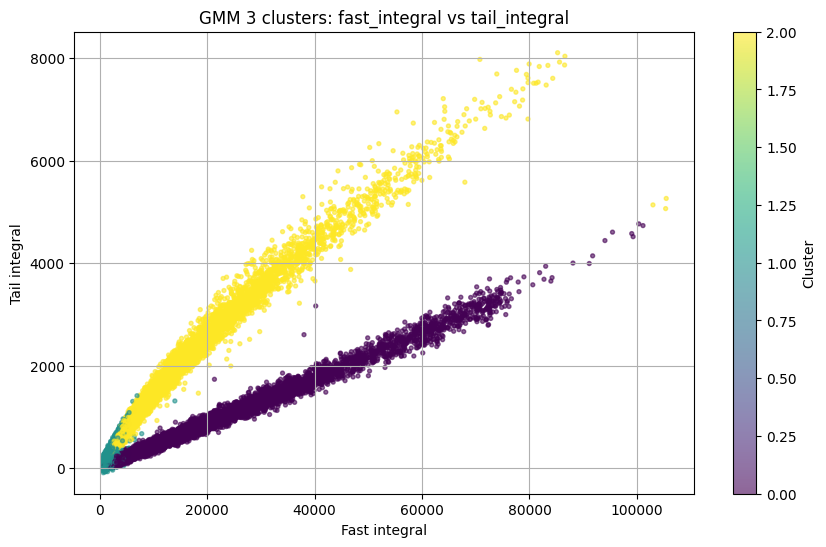

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    features["fast_integral"],
    features["tail_integral"],
    c=features["cluster_gmm3"],
    s=8,
    alpha=0.6,
    cmap="viridis"
)

plt.title("GMM 3 clusters: fast_integral vs tail_integral")
plt.xlabel("Fast integral")
plt.ylabel("Tail integral")
plt.grid(True)
plt.colorbar(label="Cluster")
plt.show()

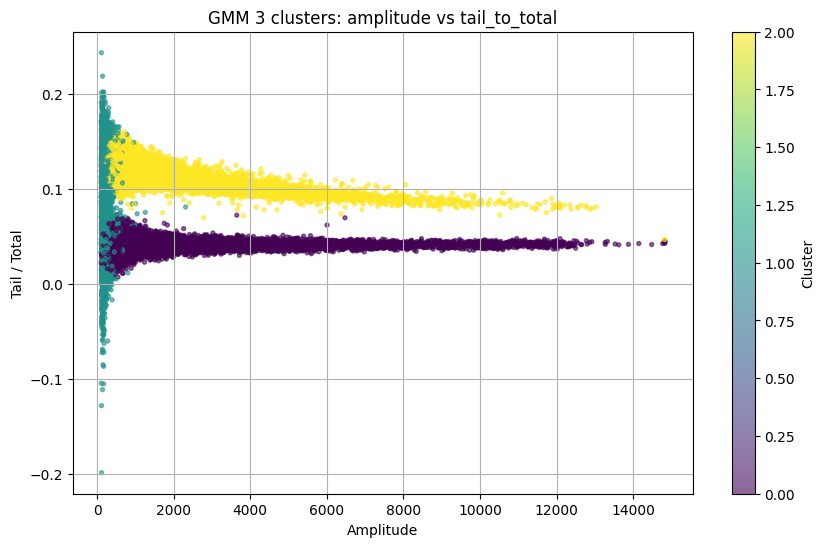

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    features["amplitude"],
    features["tail_to_total"],
    c=features["cluster_gmm3"],
    s=8,
    alpha=0.6,
    cmap="viridis"
)

plt.title("GMM 3 clusters: amplitude vs tail_to_total")
plt.xlabel("Amplitude")
plt.ylabel("Tail / Total")
plt.grid(True)
plt.colorbar(label="Cluster")
plt.show()

In [ ]:
# Submission GMM

mapping_gmm_physical = {
    0: 0,  # нижняя ветвь, малый хвост
    2: 1,  # верхняя ветвь, большой хвост
    1: 2   # слабые / неидентифицируемые сигналы
}

features["cluster_gmm_physical"] = (
    features["cluster_gmm3"]
    .map(mapping_gmm_physical)
    .astype(int)
)

print("Размеры финальных GMM-кластеров:")
print(features["cluster_gmm_physical"].value_counts().sort_index())

submission_gmm_physical = pd.DataFrame({
    "index": features.index,
    "cluster": features["cluster_gmm_physical"].values
})

submission_gmm_physical.to_csv("submission_gmm_physical.csv", index=False)

display(submission_gmm_physical.head())

Размеры финальных GMM-кластеров:
cluster_gmm_physical
0    9019
1    8393
2    6067
Name: count, dtype: int64


,index,cluster
0,0,1
1,1,0
2,2,0
3,3,1
4,4,0


In [ ]:
from google.colab import files
files.download("submission_gmm_physical.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from itertools import permutations

base_labels = features["cluster_gmm3"].values

for perm in permutations([0, 1, 2]):
    mapping = {
        0: perm[0],
        1: perm[1],
        2: perm[2]
    }

    labels_perm = pd.Series(base_labels).map(mapping).values

    submission_perm = pd.DataFrame({
        "index": features.index,
        "cluster": labels_perm
    })

    filename = f"submission_gmm_rawperm_{perm[0]}_{perm[1]}_{perm[2]}.csv"
    submission_perm.to_csv(filename, index=False)

    print(filename, mapping, submission_perm["cluster"].value_counts().sort_index().to_dict())

submission_gmm_rawperm_0_1_2.csv {0: 0, 1: 1, 2: 2} {0: 9019, 1: 6067, 2: 8393}
submission_gmm_rawperm_0_2_1.csv {0: 0, 1: 2, 2: 1} {0: 9019, 1: 8393, 2: 6067}
submission_gmm_rawperm_1_0_2.csv {0: 1, 1: 0, 2: 2} {0: 6067, 1: 9019, 2: 8393}
submission_gmm_rawperm_1_2_0.csv {0: 1, 1: 2, 2: 0} {0: 8393, 1: 9019, 2: 6067}
submission_gmm_rawperm_2_0_1.csv {0: 2, 1: 0, 2: 1} {0: 6067, 1: 8393, 2: 9019}
submission_gmm_rawperm_2_1_0.csv {0: 2, 1: 1, 2: 0} {0: 8393, 1: 6067, 2: 9019}


In [ ]:
from google.colab import files
files.download("submission_gmm_rawperm_2_1_0.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Эксперимент 4. GMM на PSD-признаках

psd_features = [
    "tail_to_total",
    "tail_to_fast",
    "integral_to_amplitude"
]

X_psd = features[psd_features].copy()

from sklearn.preprocessing import StandardScaler

scaler_psd = StandardScaler()
X_psd_scaled = scaler_psd.fit_transform(X_psd)

X_psd_scaled = pd.DataFrame(
    X_psd_scaled,
    columns=psd_features,
    index=features.index
)

display(X_psd.head())

,tail_to_total,tail_to_fast,integral_to_amplitude
0,0.139749,0.182650,8.703526
1,0.044801,0.048823,6.493923
2,0.031448,0.033598,6.628432
3,0.116058,0.143509,8.247751
4,0.040910,0.043326,6.471398


In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

gmm_psd = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42,
    n_init=30
)

clusters_gmm_psd = gmm_psd.fit_predict(X_psd_scaled)

features["cluster_gmm_psd"] = clusters_gmm_psd

print("Размеры GMM PSD-кластеров:")
print(features["cluster_gmm_psd"].value_counts().sort_index())

print("\nМетрики:")
print("Silhouette:", silhouette_score(X_psd_scaled, clusters_gmm_psd))
print("Davies-Bouldin:", davies_bouldin_score(X_psd_scaled, clusters_gmm_psd))
print("Calinski-Harabasz:", calinski_harabasz_score(X_psd_scaled, clusters_gmm_psd))

Размеры GMM PSD-кластеров:
cluster_gmm_psd
0    8946
1    6405
2    8128
Name: count, dtype: int64

Метрики:
Silhouette: 0.3955388013404275
Davies-Bouldin: 2.6602869708334924
Calinski-Harabasz: 14717.63882242652


In [ ]:
display(
    features.groupby("cluster_gmm_psd")[[
        "amplitude",
        "total_integral",
        "fast_integral",
        "tail_integral",
        "tail_to_total",
        "tail_to_fast",
        "integral_to_amplitude",
        "peak_pos",
        "late_max_to_amplitude",
        "late_integral_to_total"
    ]].median()
)

,amplitude,total_integral,fast_integral,tail_integral,tail_to_total,tail_to_fast,integral_to_amplitude,peak_pos,late_max_to_amplitude,late_integral_to_total
cluster_gmm_psd,,,,,,,,,,
0,1530.27,9700.0,9103.625,397.9,0.040767,0.043424,6.355442,150.0,0.004662,0.001919
1,219.27,1824.0,1504.750,180.2,0.104296,0.129358,8.624206,148.0,0.030564,0.008945
2,1308.26,11602.0,9333.375,1359.5,0.114030,0.140614,8.696498,150.0,0.007570,0.007073


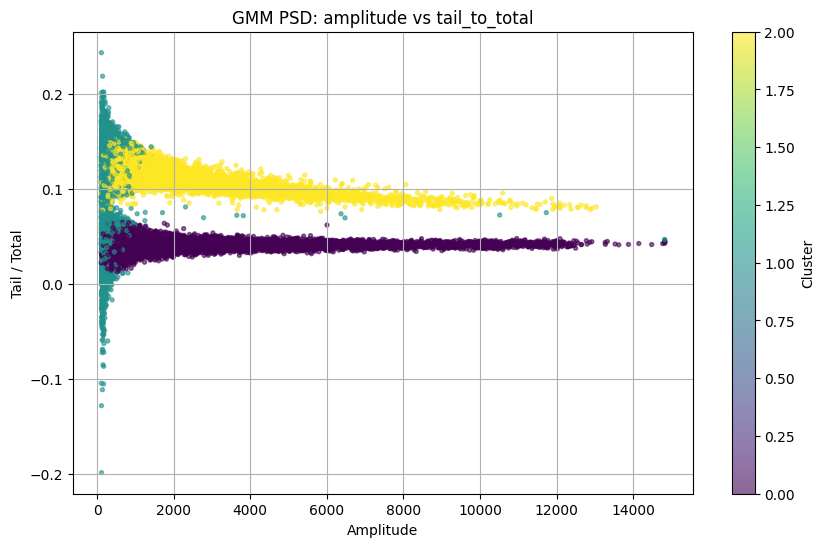

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    features["amplitude"],
    features["tail_to_total"],
    c=features["cluster_gmm_psd"],
    s=8,
    alpha=0.6,
    cmap="viridis"
)

plt.title("GMM PSD: amplitude vs tail_to_total")
plt.xlabel("Amplitude")
plt.ylabel("Tail / Total")
plt.grid(True)
plt.colorbar(label="Cluster")
plt.show()

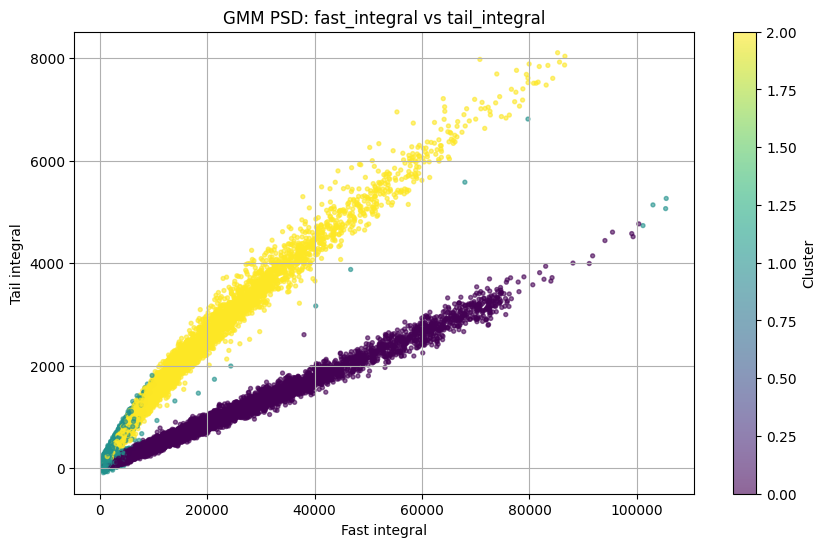

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    features["fast_integral"],
    features["tail_integral"],
    c=features["cluster_gmm_psd"],
    s=8,
    alpha=0.6,
    cmap="viridis"
)

plt.title("GMM PSD: fast_integral vs tail_integral")
plt.xlabel("Fast integral")
plt.ylabel("Tail integral")
plt.grid(True)
plt.colorbar(label="Cluster")
plt.show()

In [ ]:
from itertools import permutations

base_labels = features["cluster_gmm_psd"].values

for perm in permutations([0, 1, 2]):
    mapping = {
        0: perm[0],
        1: perm[1],
        2: perm[2]
    }

    labels_perm = pd.Series(base_labels).map(mapping).values

    submission_perm = pd.DataFrame({
        "index": features.index,
        "cluster": labels_perm
    })

    filename = f"submission_gmm_psd_perm_{perm[0]}_{perm[1]}_{perm[2]}.csv"
    submission_perm.to_csv(filename, index=False)

    print(filename, mapping, submission_perm["cluster"].value_counts().sort_index().to_dict())

submission_gmm_psd_perm_0_1_2.csv {0: 0, 1: 1, 2: 2} {0: 8946, 1: 6405, 2: 8128}
submission_gmm_psd_perm_0_2_1.csv {0: 0, 1: 2, 2: 1} {0: 8946, 1: 8128, 2: 6405}
submission_gmm_psd_perm_1_0_2.csv {0: 1, 1: 0, 2: 2} {0: 6405, 1: 8946, 2: 8128}
submission_gmm_psd_perm_1_2_0.csv {0: 1, 1: 2, 2: 0} {0: 8128, 1: 8946, 2: 6405}
submission_gmm_psd_perm_2_0_1.csv {0: 2, 1: 0, 2: 1} {0: 6405, 1: 8128, 2: 8946}
submission_gmm_psd_perm_2_1_0.csv {0: 2, 1: 1, 2: 0} {0: 8128, 1: 6405, 2: 8946}


In [ ]:
from google.colab import files
files.download("submission_gmm_psd_perm_2_1_0.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("submission_gmm_psd_perm_1_2_0.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("submission_gmm_psd_perm_0_2_1.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("submission_gmm_psd_perm_2_0_1.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Финальная модель: GMM PSD
# Лучший mapping по Kaggle score

best_mapping = {
    0: 1,
    1: 2,
    2: 0
}

features["cluster_final_best"] = (
    features["cluster_gmm_psd"]
    .map(best_mapping)
    .astype(int)
)

print("Best mapping:", best_mapping)
print("Размеры финальных кластеров:")
print(features["cluster_final_best"].value_counts().sort_index())

submission_best = pd.DataFrame({
    "index": features.index,
    "cluster": features["cluster_final_best"].values
})

submission_best.to_csv("submission_best_gmm_psd.csv", index=False)

display(submission_best.head())